In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import os

from pyqg_parameterization_benchmarks.utils import energy_budget_figure
import pyqg_parameterization_benchmarks as ppb
from utils import*
from matplotlib.gridspec import GridSpec

In [2]:
config = 'eddy'
nx_hires = 256
nx_lores = 64
dt = 3600.0
sampling_freq = 1000
stable_start = 31
num_snapshots = 87
operator_id = 3
n_components = 1
lamb = 0.01
max_step = 201
tolerance = 5

# Offline Results

In [3]:
def test_offline(target, prediction, key):
    """Evaluate the parameterization on an offline dataset,
    computing a variety of metrics."""

    test = xr.Dataset({'q': target}).copy(deep=True)
    truth = test[key]
    test[f"{key}_predictions"] = truth * 0 + prediction
    preds = test[f"{key}_predictions"]

    error = (truth - preds) ** 2

    true_centered = (truth - truth.mean())
    pred_centered = (preds - preds.mean())
    true_var = true_centered ** 2
    pred_var = pred_centered ** 2
    true_pred_cov = true_centered * pred_centered

    def dims_except(*dims):
        return [d for d in test[key].dims if d not in dims]

    time = dims_except('x', 'y', 'lev')
    space = dims_except('time', 'lev')
    both = dims_except('lev')

    test[f"{key}_spatial_mse"] = error.mean(dim=time)
    test[f"{key}_temporal_mse"] = error.mean(dim=space)
    test[f"{key}_mse"] = error.mean(dim=both)

    test[f"{key}_spatial_skill"] = 1 - test[f"{key}_spatial_mse"] / true_var.mean(dim=time)
    test[f"{key}_temporal_skill"] = 1 - test[f"{key}_temporal_mse"] / true_var.mean(dim=space)
    test[f"{key}_skill"] = 1 - test[f"{key}_mse"] / true_var.mean(dim=both)

    test[f"{key}_spatial_correlation"] = xr.corr(truth, preds, dim=time)
    test[f"{key}_temporal_correlation"] = xr.corr(truth, preds, dim=space)
    test[f"{key}_correlation"] = xr.corr(truth, preds, dim=both)

    return test

## Load offline data

In [4]:
# Load the data
suffix = f"{nx_hires}_{nx_lores}_{int(dt)}_{sampling_freq}_{stable_start}_{num_snapshots}"
ksd_suffix = (f"{nx_hires}_{nx_lores}_{int(dt)}_{sampling_freq}_{stable_start}_{num_snapshots}_{n_components}"
               f"_{lamb}_{max_step}_{tolerance}")
base_dir = "data"

low_res_model = xr.open_zarr(os.path.join(base_dir, f"low_res_model_{config}_3_{suffix}.zarr")).isel(run=slice(0, 5))
low_res_truth = xr.open_zarr(os.path.join(base_dir, f"low_res_truth_{config}_3_{suffix}.zarr")).isel(run=slice(0, 5))
low_res_ksd = xr.open_zarr(os.path.join(base_dir, f"low_res_cali_{config}_3_{ksd_suffix}.zarr"))['q'].isel(run=slice(0, 5))

## Offline $R^2$ and MSE

In [5]:
low_res_model_q = low_res_model.q
low_res_truth_q = low_res_truth.q

model_truth_metric = test_offline(low_res_truth_q, low_res_model_q, 'q')
ksd_truth_metric = test_offline(low_res_truth_q, low_res_ksd, 'q')

print(f"Model R2 lev 1: {model_truth_metric.q_skill.values[0]:.4f}")
print(f"Model R2 lev 2: {model_truth_metric.q_skill.values[1]:.4f}")
print(f"KSD R2 lev 1: {ksd_truth_metric.q_skill.values[0]:.4f}")
print(f"KSD R2 lev 2: {ksd_truth_metric.q_skill.values[1]:.4f}")
print(f"Model MSE lev 1: {model_truth_metric.q_mse.values[0]:.4e}")
print(f"Model MSE lev 2: {model_truth_metric.q_mse.values[1]:.4e}")
print(f"KSD MSE lev 1: {ksd_truth_metric.q_mse.values[0]:.4e}")
print(f"KSD MSE lev 2: {ksd_truth_metric.q_mse.values[1]:.4e}")

Model R2 lev 1: 0.5332
Model R2 lev 2: 0.8444
KSD R2 lev 1: 0.5366
KSD R2 lev 2: 0.8453
Model MSE lev 1: 2.8421e-11
Model MSE lev 2: 1.8135e-13
KSD MSE lev 1: 2.8217e-11
KSD MSE lev 2: 1.8029e-13


# Online Results

## Load online data

In [6]:
# reference high-res simulation
suffix = f"{config}_{nx_hires}_{nx_lores}_{int(dt)}_{sampling_freq}_{stable_start}_{num_snapshots}"
highres = xr.open_zarr(f"data/high_res_{suffix}.zarr").isel(run=slice(0, 5))
# low-res
suffix = f"{config}_{operator_id}_{nx_hires}_{nx_lores}_{int(dt)}_{sampling_freq}_{stable_start}_{num_snapshots}"
lowres = xr.open_zarr(f"data/online_low_res_{suffix}.zarr").isel(run=slice(0, 5))

In [7]:
# low-res-FCNN
datasets = []
# Loop over all input-target combinations
for input_id in range(1, 8):
    for target_id in range(1, 6):
        if config == 'jet' and ((operator_id, input_id, target_id) == (3, 1, 1)
                                or (operator_id, input_id, target_id) == (1, 3, 1)
                                or (operator_id, input_id, target_id) == (1, 5, 1)
                                or (operator_id, input_id, target_id) == (3, 1, 2)
                                or (operator_id, input_id, target_id) == (1, 3, 2)
                                or (operator_id, input_id, target_id) == (2, 3, 2)
                                or (operator_id, input_id, target_id) == (1, 5, 2)
                                or (operator_id, input_id, target_id) == (2, 3, 3)):
            print('Under this setting, low res + FCNN will violate CFL condition.')
            continue
        # Construct the filename suffix
        suffix = f"{config}_{operator_id}_{nx_hires}_{nx_lores}_{int(dt)}_{sampling_freq}_{stable_start}_{num_snapshots}_fcnn_{input_id}_{target_id}"
        path = f"data/online_low_res_{suffix}.zarr"
        try:
            # Open the Zarr dataset
            ds = xr.open_zarr(path)

            # Check for NaNs in 'q' along the 'run' dimension
            if "run" in ds.dims:
                valid_runs = []
                for i in range(ds.sizes["run"]):
                    q_values = ds["q"].isel(run=i)
                    if not np.isnan(q_values).any():
                        valid_runs.append(ds.isel(run=i))
                    else:
                        print(f"NaN detected in file: {path}, run index: {i}")
                if valid_runs:
                    cleaned_ds = xr.concat(valid_runs, dim="run")
                    datasets.append(cleaned_ds)
            else:
                # If 'run' is not a dimension, check directly
                if not np.isnan(ds["q"]).any():
                    datasets.append(ds)
                else:
                    print(f"NaN detected in file without 'run' dimension: {path}")
        except FileNotFoundError:
            print(f"File not found: {path}")
# Concatenate all datasets along the 'run' dimension
lowres_FCNN = xr.concat(datasets, dim="run")
# Reset the 'run' coordinate to ensure unique values
lowres_FCNN["run"] = range(lowres_FCNN.sizes["run"])

In [8]:
# low-res-ksd
suffix = f"{config}_{operator_id}_{nx_hires}_{nx_lores}_{int(dt)}_{sampling_freq}_{stable_start}_{num_snapshots}"
ksd_suffix = (f"{config}_{operator_id}_{nx_hires}_{nx_lores}_{int(dt)}_{sampling_freq}_{stable_start}"
               f"_{num_snapshots}_cali_{n_components}_{lamb}_{max_step}_{tolerance}")
lowres_ksd = xr.open_zarr(f"data/online_low_res_{ksd_suffix}.zarr").isel(run=slice(0, 5))

In [9]:
# low-res-FCNN-ksd
datasets = []
# Loop over all input-target combinations
for input_id in range(1, 8):
    for target_id in range(1, 6):
        if config == 'jet' and ((operator_id, input_id, target_id) == (3, 1, 1)
                                or (operator_id, input_id, target_id) == (1, 3, 1)
                                or (operator_id, input_id, target_id) == (1, 5, 1)
                                or (operator_id, input_id, target_id) == (3, 1, 2)
                                or (operator_id, input_id, target_id) == (1, 3, 2)
                                or (operator_id, input_id, target_id) == (2, 3, 2)
                                or (operator_id, input_id, target_id) == (1, 5, 2)
                                or (operator_id, input_id, target_id) == (2, 3, 3)):
            print('Under this setting, low res + FCNN will violate CFL condition.')
            continue
        # Construct the filename suffix
        suffix = f"{config}_{operator_id}_{nx_hires}_{nx_lores}_{int(dt)}_{sampling_freq}_{stable_start}_{num_snapshots}_fcnn_{input_id}_{target_id}_cali_{n_components}_{lamb}_{max_step}_{tolerance}"
        path = f"data/online_low_res_{suffix}.zarr"
        try:
            # Open the Zarr dataset
            ds = xr.open_zarr(path)

            # Check for NaNs in 'q' along the 'run' dimension
            if "run" in ds.dims:
                valid_runs = []
                for i in range(ds.sizes["run"]):
                    q_values = ds["q"].isel(run=i)
                    if not np.isnan(q_values).any():
                        valid_runs.append(ds.isel(run=i))
                    else:
                        print(f"NaN detected in file: {path}, run index: {i}")
                if valid_runs:
                    cleaned_ds = xr.concat(valid_runs, dim="run")
                    datasets.append(cleaned_ds)
            else:
                # If 'run' is not a dimension, check directly
                if not np.isnan(ds["q"]).any():
                    datasets.append(ds)
                else:
                    print(f"NaN detected in file without 'run' dimension: {path}")
        except FileNotFoundError:
            print(f"File not found: {path}")

# Concatenate all datasets along the 'run' dimension
lowres_FCNN_ksd = xr.concat(datasets, dim="run")
# Reset the 'run' coordinate to ensure unique values
lowres_FCNN_ksd["run"] = range(lowres_FCNN_ksd.sizes["run"])

# Figure 1

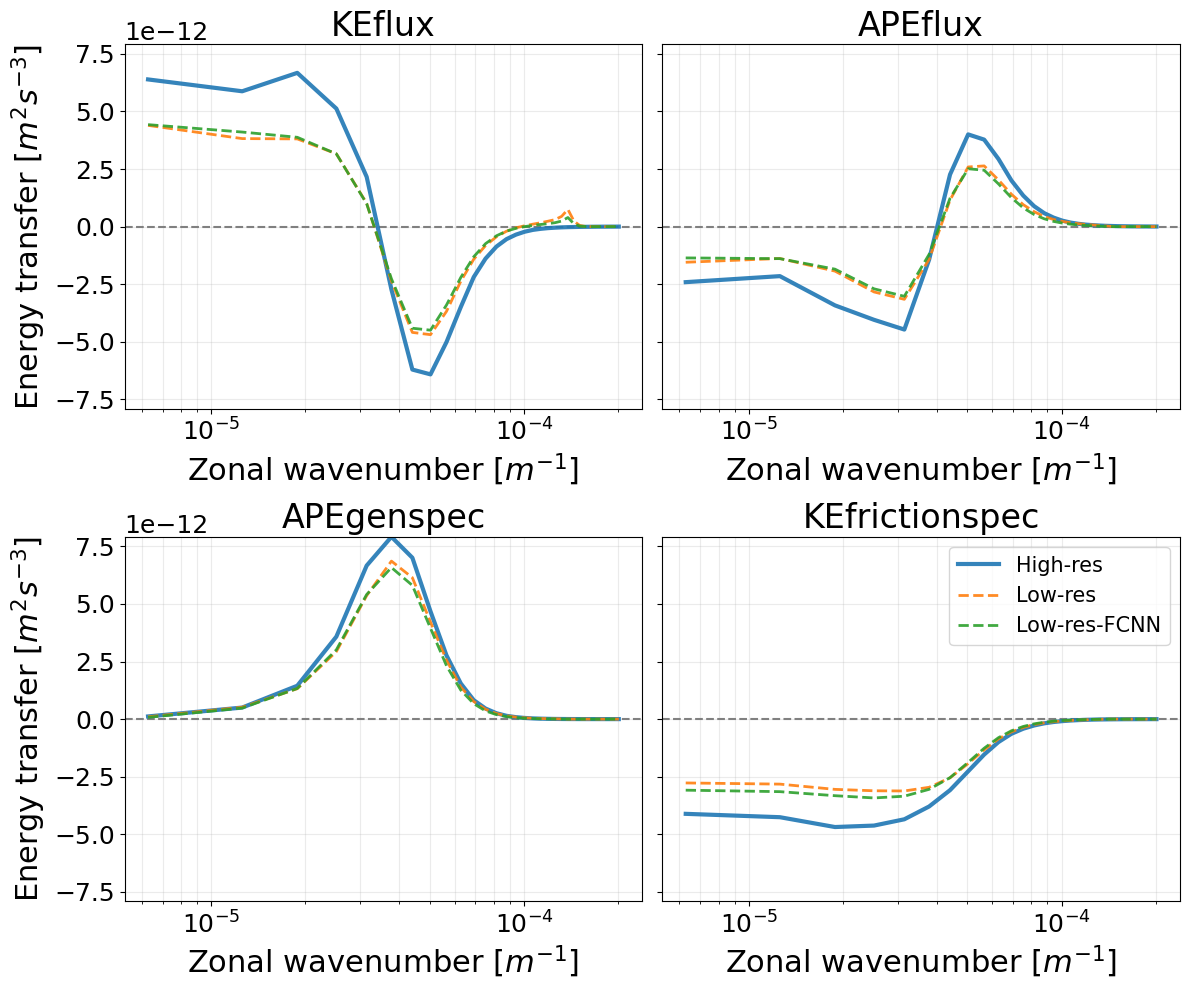

In [10]:
sims = [(highres, 'High-res'),
        (lowres, f'Low-res'),
        (lowres_FCNN, f'Low-res-FCNN'),]
colors = None
linestyles = ['-', '--', '--']
linewidths = [3, 2, 2]

fig = energy_budget_figure(sims, colors, linestyles, linewidths, layout="2x2")
# fig.suptitle(f"Energy budget comparison, with Config {config}, Operator {operator_id}", fontsize=24)
plt.tight_layout(rect=[0.0, 0.0, 1.0, 1.0])
plt.savefig(f'figs/online_energy_{suffix}.png')
plt.savefig(f'figs/online_energy_{suffix}.pdf')
plt.show()

# Figure 5

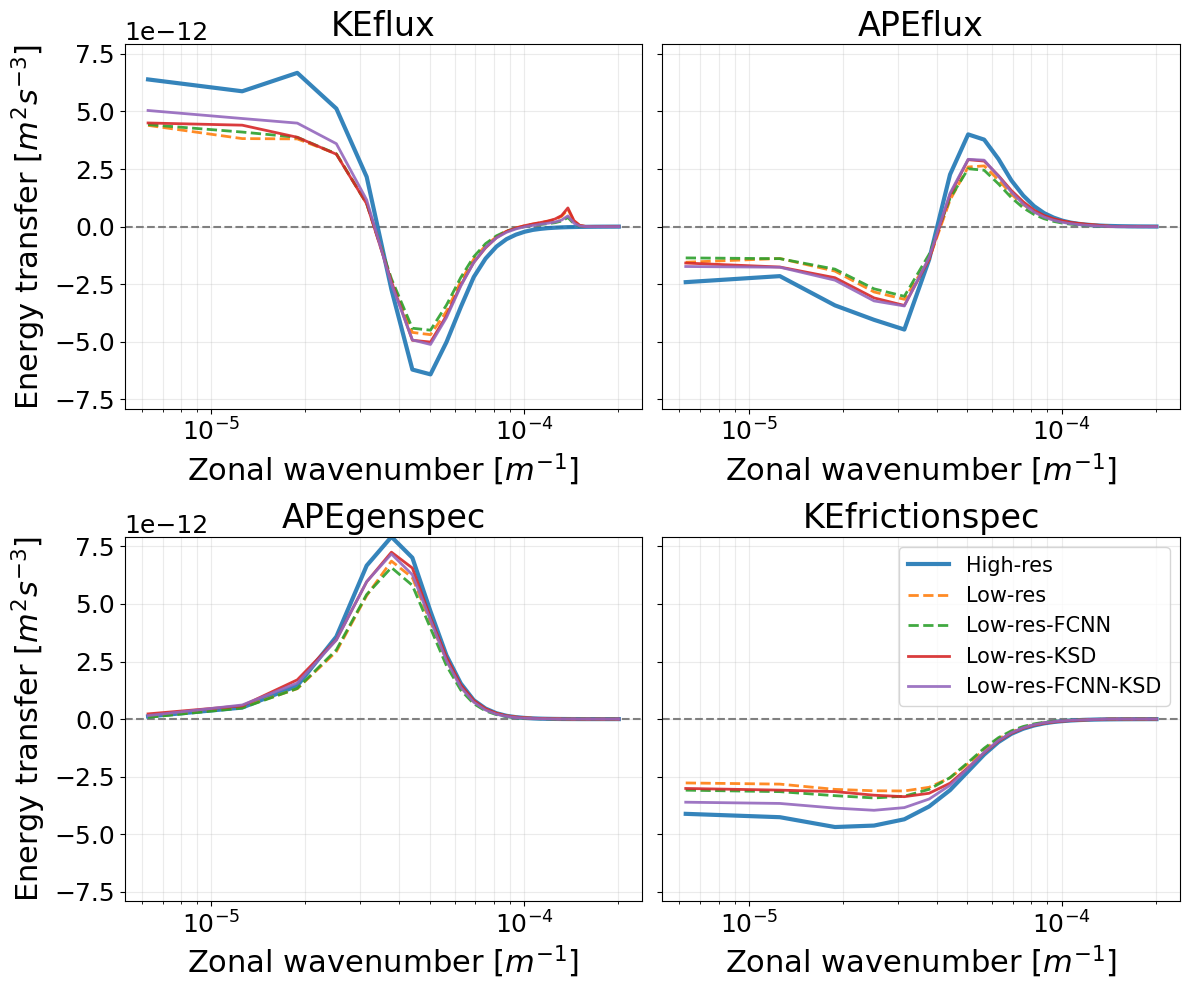

In [11]:
sims = [(highres, 'High-res'),
        (lowres, f'Low-res'),
        (lowres_FCNN, f'Low-res-FCNN'),
        (lowres_ksd, f'Low-res-KSD'),
        (lowres_FCNN_ksd, f'Low-res-FCNN-KSD'),]
# colors = ['darkblue', 'orange', 'darkred', 'plum', 'indigo']
colors = None
linestyles = ['-', '--', '--', '-', '-']
linewidths = [3, 2, 2, 2, 2]

fig = energy_budget_figure(sims, colors, linestyles, linewidths, layout="2x2")
# fig.suptitle(f"Energy budget comparison, with Config {config}, Operator {operator_id}", fontsize=24)
plt.tight_layout(rect=[0.0, 0.0, 1.0, 1.0])
plt.savefig(f'figs/online_energy_{ksd_suffix}.png')
plt.savefig(f'figs/online_energy_{ksd_suffix}.pdf')
plt.show()

# Figure 6

In [12]:
l = len(sims)
for i in range(1, l):
    for j in range(1, l):
        if i == j:
            continue
        sim = ppb.diagnostic_similarities(sims[j][0], target=sims[0][0], baseline=sims[i][0])
        print(f"Comparison between model {sims[j][1]} and baseline {sims[i][1]}:")
        for k, v in sim.items():
            print(f"{k}: {v}")
        print()

Comparison between model Low-res-FCNN and baseline Low-res:
distrib_diff_q1: -0.05969317075547398
distrib_diff_q2: 0.027204076627013185
distrib_diff_u1: 0.0629895222196537
distrib_diff_u2: 0.27563141001766556
distrib_diff_v1: -0.03416711242662385
distrib_diff_v2: 0.26588617935609105
distrib_diff_KE1: 0.003570286836339309
distrib_diff_KE2: 0.24210593140690284
distrib_diff_Ens1: -0.2095950014687462
distrib_diff_Ens2: 0.04818275741894684
spectral_diff_KEspec1: 0.081269838911039
spectral_diff_KEspec2: 0.19750382485491336
spectral_diff_Ensspec1: 0.07576547476980877
spectral_diff_Ensspec2: 0.00027005572877836226
spectral_diff_KEflux: 0.007558685357833439
spectral_diff_APEflux: -0.07668929891665388
spectral_diff_APEgenspec: -0.18255889553121496
spectral_diff_KEfrictionspec: 0.19750382485491347

Comparison between model Low-res-KSD and baseline Low-res:
distrib_diff_q1: 0.3257240255732986
distrib_diff_q2: 0.6377087315207257
distrib_diff_u1: 0.42649330168903254
distrib_diff_u2: 0.33497597235318

In [13]:
# Setup
models = ['Low-res', 'FCNN', 'Low-res-KSD', 'FCNN-KSD']
metrics = ['KEflux', 'APEflux', 'APEgenspec', 'KEfrictionspec']
data_entries = {
    ('FCNN', 'Low-res'): [0.0076, -0.0767, -0.1826, 0.1975],
    ('Low-res-KSD', 'Low-res'): [0.1173, 0.1770, 0.4108, 0.1264],
    ('FCNN-KSD', 'Low-res'): [0.2809, 0.2603, 0.3391, 0.5536],
    ('Low-res-KSD', 'FCNN'): [0.1105, 0.2357, 0.5017, -0.0886],
    ('FCNN-KSD', 'FCNN'): [0.2754, 0.3130, 0.4411, 0.4437],
    ('FCNN-KSD', 'Low-res-KSD'): [0.1853, 0.1012, -0.1217, 0.4890]
}

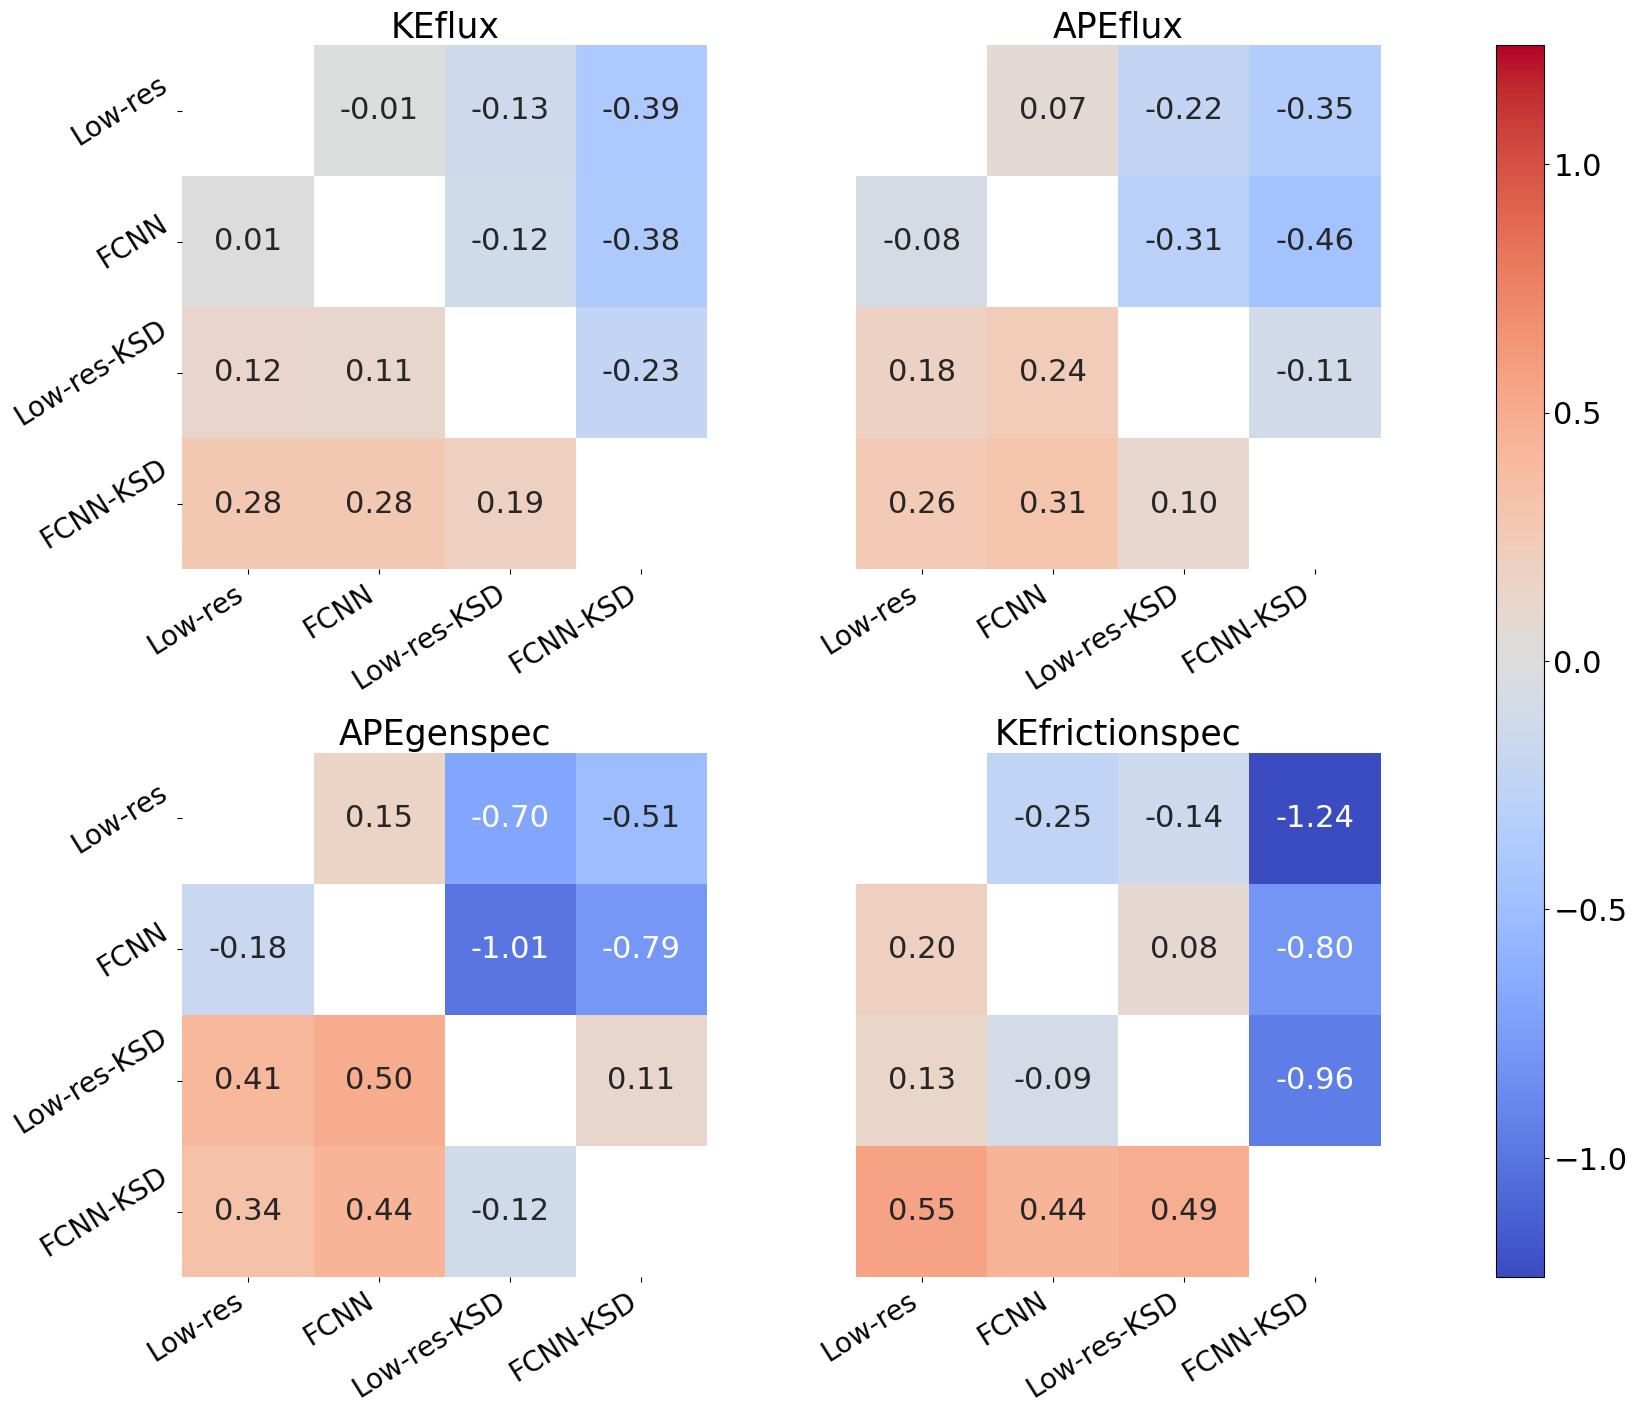

In [14]:
def compute_reverse(v):
    return 1 - 1 / (1 - v)

# Prepare heatmaps
heatmaps = {metric: np.full((4, 4), np.nan) for metric in metrics}
model_idx = {name: i for i, name in enumerate(models)}

for (m, b), vals in data_entries.items():
    i, j = model_idx[m], model_idx[b]
    for k, metric in enumerate(metrics):
        heatmaps[metric][i, j] = vals[k]
        heatmaps[metric][j, i] = compute_reverse(vals[k])

global_max = max(np.nanmax(np.abs(heatmaps[metric])) for metric in metrics)

# ============================================================
# Create a figure with a dedicated colorbar column (3 columns total)
# ============================================================
fig = plt.figure(figsize=(18, 16))   # Large height prevents overlap
gs = GridSpec(
    2, 3,
    width_ratios=[1, 1, 0.08],   # last column reserved for colorbar
    wspace=0.20,
    hspace=0.35                  # large height spacing avoids any overlap
)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1])
]

cmap = plt.get_cmap('coolwarm')
norm = plt.Normalize(vmin=-global_max, vmax=global_max)
img = None

# Draw heatmaps
for idx, metric in enumerate(metrics):
    ax = axes[idx]

    show_y_labels = (idx % 2 == 0)

    img = sns.heatmap(
        heatmaps[metric],
        annot=True,
        fmt=".2f",
        cmap=cmap,
        norm=norm,
        xticklabels=models,
        yticklabels=models if show_y_labels else False,
        cbar=False,
        ax=ax,
        annot_kws={"size": 22},
        square=True
    )

    ax.set_title(metric, fontsize=25)

    for label in ax.get_xticklabels():
        label.set(rotation=32, ha='right', fontsize=20)
    for label in ax.get_yticklabels():
        label.set(rotation=32, ha='right', fontsize=20)

    ax.tick_params(axis='y', labelsize=20 if show_y_labels else 0)

    if not show_y_labels:
        ax.set_yticks([])

# ============================================================
# Dedicated colorbar column (always perfectly centered)
# ============================================================
cbar_ax = fig.add_subplot(gs[:, 2])   # span both rows

cbar = fig.colorbar(img.collections[0], cax=cbar_ax)
cbar.ax.tick_params(labelsize=22)

plt.savefig('figs/online_score_eddy_operator3.png', dpi=300)
plt.savefig('figs/online_score_eddy_operator3.pdf')
plt.show()